In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from os.path import exists

sys.path.append('../..')

In [3]:
from collections import defaultdict

In [4]:
import pylab as plt
import pandas as pd
import numpy as np
from loguru import logger
import seaborn as sns

from stable_baselines3 import PPO, DQN

In [5]:
from vimms.Common import POSITIVE, set_log_level_warning, load_obj, save_obj
from vimms.ChemicalSamplers import UniformRTAndIntensitySampler, GaussianChromatogramSampler, UniformMZFormulaSampler, \
    MZMLFormulaSampler, MZMLRTandIntensitySampler, MZMLChromatogramSampler
from vimms.Noise import UniformSpikeNoise
from vimms.Evaluation import evaluate_real
from vimms.Chemicals import ChemicalMixtureFromMZML
from vimms.Roi import RoiBuilderParams, SmartRoiParams

from mass_spec_utils.data_import.mzmine import load_picked_boxes

from vimms_gym.env import DDAEnv
from vimms_gym.chemicals import generate_chemicals
from vimms_gym.evaluation import evaluate, run_method
from vimms_gym.common import METHOD_RANDOM, METHOD_FULLSCAN, METHOD_TOPN, METHOD_PPO, METHOD_DQN
from vimms_gym.visualisation import plot_N, plot_ms1_ms2_counts, plot_action_hist, plot_action_probs, plot_reward_probs

# 1. Parameters

In [6]:
# n_chemicals = (200, 500)
# mz_range = (100, 600)
# rt_range = (0, 300)
# intensity_range = (1E5, 1E10)

In [7]:
n_chemicals = (2000, 5000)
mz_range = (100, 600)
rt_range = (200, 1000)
intensity_range = (1E4, 1E10)

In [8]:
min_mz = mz_range[0]
max_mz = mz_range[1]
min_rt = rt_range[0]
max_rt = rt_range[1]
min_log_intensity = np.log(intensity_range[0])
max_log_intensity = np.log(intensity_range[1])

In [9]:
isolation_window = 0.7
N = 10
rt_tol = 120
exclusion_t_0 = 15
mz_tol = 10
min_ms1_intensity = 5000
ionisation_mode = POSITIVE

enable_spike_noise = True
noise_density = 0.1
noise_max_val = 1E3

In [10]:
mz_sampler = UniformMZFormulaSampler(min_mz=min_mz, max_mz=max_mz)
ri_sampler = UniformRTAndIntensitySampler(min_rt=min_rt, max_rt=max_rt,
                                          min_log_intensity=min_log_intensity,
                                          max_log_intensity=max_log_intensity)
cr_sampler = GaussianChromatogramSampler()
samplers = {
    'mz': mz_sampler,
    'rt_intensity': ri_sampler,
    'chromatogram': cr_sampler
}

In [11]:
params = {
    'chemical_creator': {
        'mz_range': mz_range,
        'rt_range': rt_range,
        'intensity_range': intensity_range,
        'n_chemicals': n_chemicals,
        'mz_sampler': mz_sampler,
        'ri_sampler': ri_sampler,
        'cr_sampler': cr_sampler,
    },
    'noise': {
        'enable_spike_noise': enable_spike_noise,
        'noise_density': noise_density,
        'noise_max_val': noise_max_val,
        'mz_range': mz_range
    },
    'env': {
        'ionisation_mode': ionisation_mode,
        'rt_range': rt_range,
        'isolation_window': isolation_window,
        'mz_tol': mz_tol,
        'rt_tol': rt_tol,
    }
}

In [12]:
max_peaks = 200
in_dir = 'results'

In [13]:
n_eval_episodes = 1
deterministic = True

# 2. Evaluation

## Generate some chemical sets

In [14]:
set_log_level_warning()

1

In [15]:
chemical_creator_params = params['chemical_creator']

chem_list = []
for i in range(n_eval_episodes):
    print(i)
    chems = generate_chemicals(chemical_creator_params)
    chem_list.append(chems)

0


## Run different methods

In [16]:
eval_dir = 'visualisation'

In [17]:
for chems in chem_list:
    print(len(chems))

4511


In [18]:
max_peaks

200

In [19]:
out_dir = eval_dir
in_dir, out_dir

('results', 'visualisation')

In [20]:
all_results = {}

In [21]:
env_name = 'DDAEnv'

### Run PPO

In [22]:
method = METHOD_PPO

In [23]:
model_name = 'PPO'

In [24]:
effective_rt_tol = rt_tol
copy_params = dict(params)        
copy_params['env']['rt_tol'] = effective_rt_tol

In [25]:
fname = os.path.join(in_dir, '%s_%s.zip' % (env_name, model_name))
model = PPO.load(fname)

In [26]:
results = run_method(env_name, copy_params, max_peaks, chem_list, method, out_dir, model=model, print_eval=True, print_reward=True)


Episode 0 (4511 chemicals)
steps	 500 	total rewards	 152.757484372411
steps	 1000 	total rewards	 344.9100269965539
steps	 1500 	total rewards	 532.1276978648282
steps	 2000 	total rewards	 736.0655642504918
steps	 2500 	total rewards	 915.8813856026435
steps	 3000 	total rewards	 1100.703355796357
steps	 3500 	total rewards	 1294.891768812827
Finished after 3638 timesteps with total reward 1349.1807108472915
{'coverage_prop': '0.762', 'intensity_prop': '0.412', 'ms1/ms2 ratio': '0.110', 'efficiency': '1.048', 'TP': '1365', 'FP': '1357', 'FN': '1789', 'precision': '0.501', 'recall': '0.433', 'f1': '0.465'}


In [27]:
ppo_result = results[0]
ppo_result

### Run Top-N

In [28]:
method = METHOD_TOPN

In [29]:
effective_rt_tol = rt_tol
copy_params = dict(params)        
copy_params['env']['rt_tol'] = effective_rt_tol

In [30]:
model = None

In [31]:
results = run_method(env_name, copy_params, max_peaks, chem_list, method, out_dir, N=10, model=model, print_eval=True, print_reward=True)


Episode 0 (4511 chemicals)
steps	 500 	total rewards	 79.32565468309876
steps	 1000 	total rewards	 177.46733827295168
steps	 1500 	total rewards	 267.55361943832133
steps	 2000 	total rewards	 356.0788733145942
steps	 2500 	total rewards	 443.7948249125569
steps	 3000 	total rewards	 528.695600524966
steps	 3500 	total rewards	 612.3012120463777
Finished after 3661 timesteps with total reward 641.3464813071334
{'coverage_prop': '0.810', 'intensity_prop': '0.253', 'ms1/ms2 ratio': '0.102', 'efficiency': '1.100', 'TP': '616', 'FP': '2283', 'FN': '1612', 'precision': '0.212', 'recall': '0.276', 'f1': '0.240'}


In [32]:
topN_result = results[0]
topN_result

# 3. Visualisation

## Visualise some results from the first episode

Limit some plots to the first 1000 steps.

In [33]:
limit = 1000

Plot the distribution of N: the number of MS2 scans that follow an MS1 scan

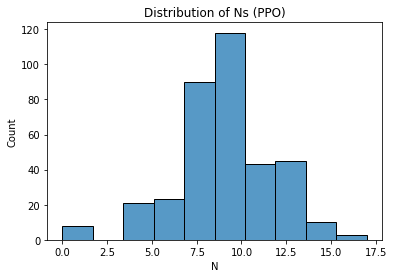

In [34]:
plot_N(ppo_result, bins=10, title='Distribution of Ns (PPO)')

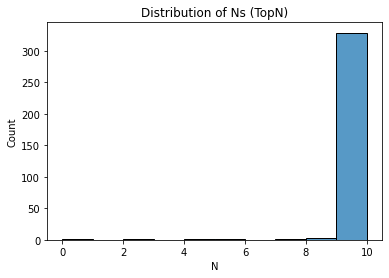

In [35]:
plot_N(topN_result, bins=10, title='Distribution of Ns (TopN)')

Plot the number of MS1 and MS2 scans over time

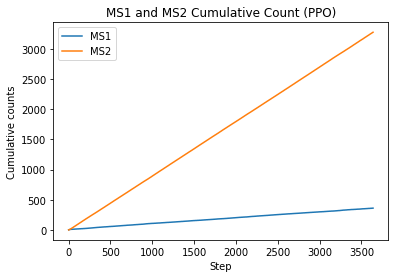

In [36]:
ppo_ms1, ppo_ms2 = plot_ms1_ms2_counts(ppo_result, title='MS1 and MS2 Cumulative Count (PPO)')

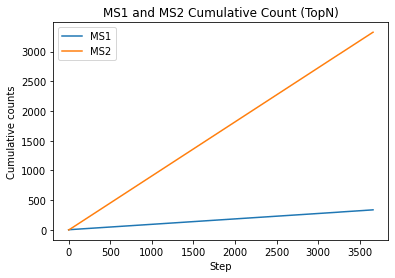

In [37]:
topN_ms1, topN_ms2 = plot_ms1_ms2_counts(topN_result, title='MS1 and MS2 Cumulative Count (TopN)')

Text(0.5, 1.0, 'MS2 Cumulative Counts')

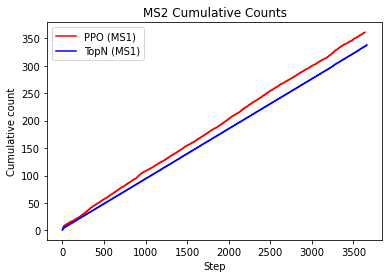

In [38]:
plt.plot(ppo_ms1, 'r-', label='PPO (MS1)')
plt.plot(topN_ms1, 'b-', label='TopN (MS1)')
plt.legend()
plt.ylabel('Cumulative count')
plt.xlabel('Step')
plt.title('MS2 Cumulative Counts')

Plot a histogram of all actions.

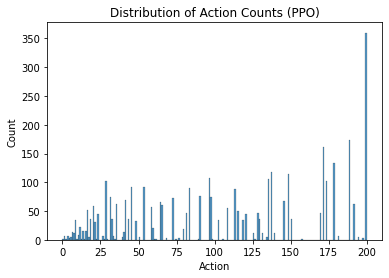

In [39]:
plot_action_hist(ppo_result, bins=200, title='Distribution of Action Counts (PPO)')

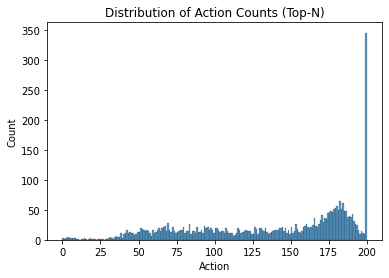

In [40]:
plot_action_hist(topN_result, bins=200, title='Distribution of Action Counts (Top-N)')

Plot a histogram of MS2-actions only

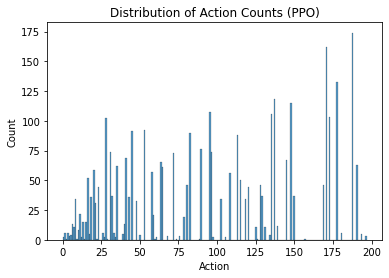

In [41]:
plot_action_hist(ppo_result, ms2_only=True, bins=199, title='Distribution of Action Counts (PPO)')

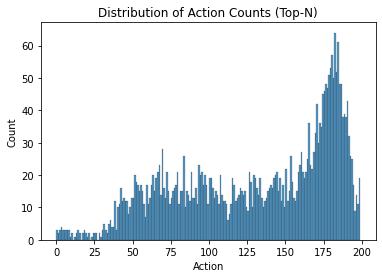

In [42]:
plot_action_hist(topN_result, ms2_only=True, bins=199, title='Distribution of Action Counts (Top-N)')

Show the first few actions

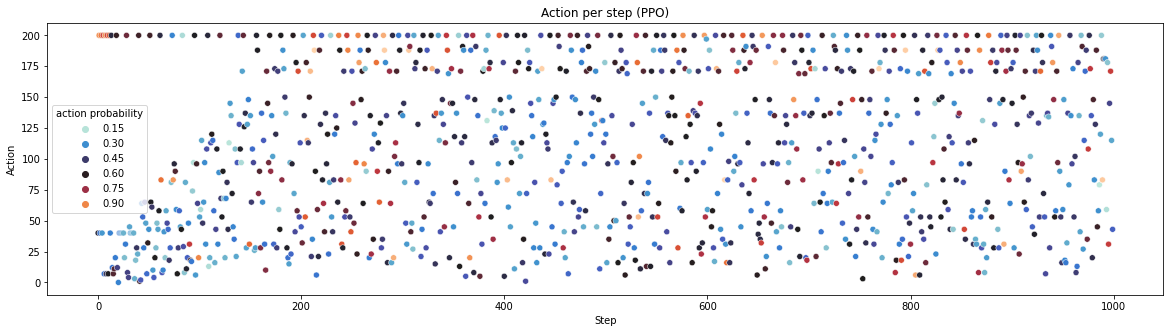

In [43]:
plot_action_probs(ppo_result, limit, max_peaks, title='Action per step (PPO)')

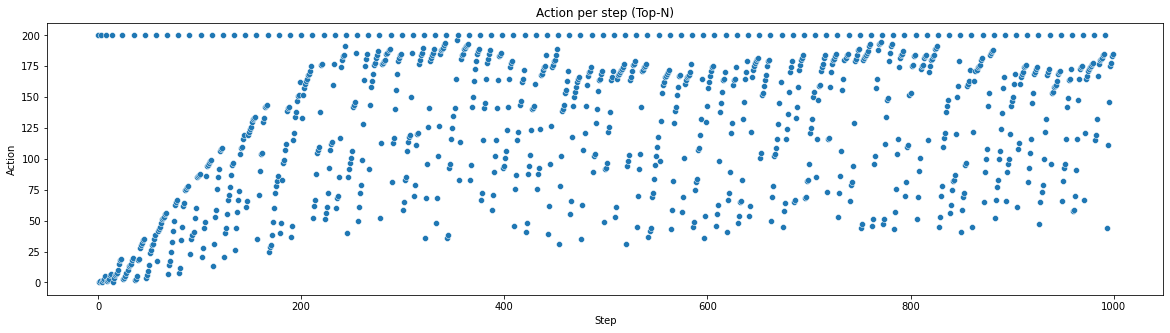

In [44]:
plot_action_probs(topN_result, limit, max_peaks, title='Action per step (Top-N)')

Plot rewards coloured by action probabilities

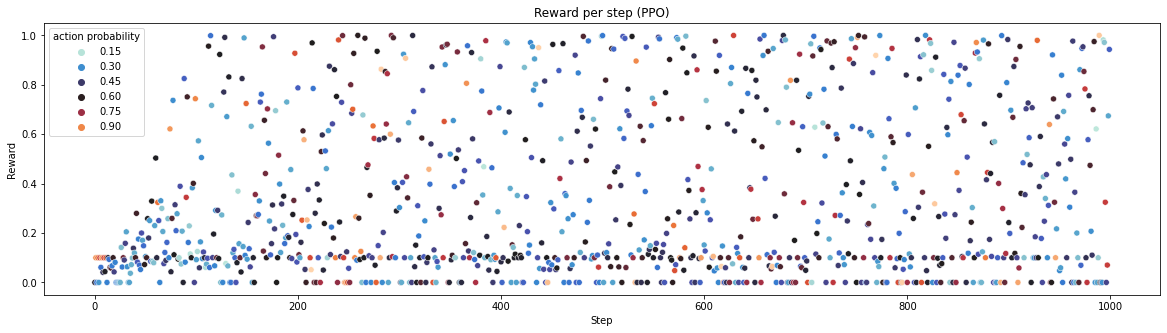

In [45]:
plot_reward_probs(ppo_result, limit, max_peaks, title='Reward per step (PPO)')

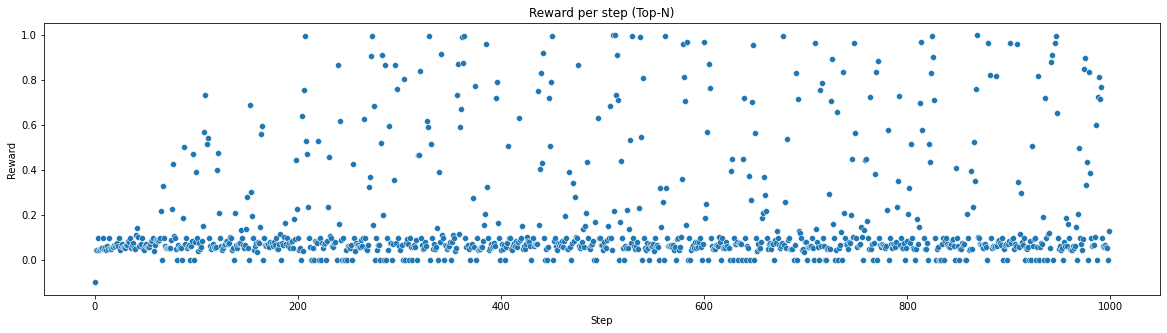

In [46]:
plot_reward_probs(topN_result, limit, max_peaks, title='Reward per step (Top-N)')